In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

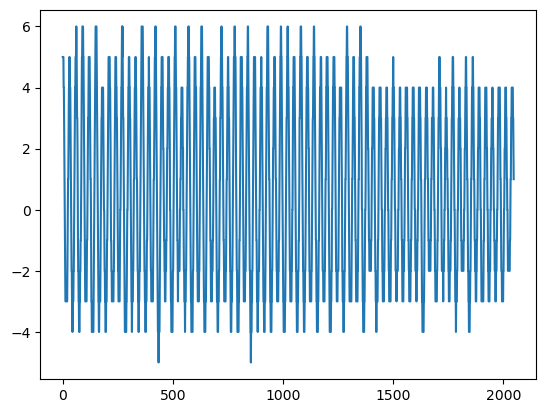

In [11]:
data = np.load("C:/Users/medin/Downloads/ASTRON121/LAB1_DATA/test_1.5MHz_50kHz.npz")
D = 2 #what sample set (1, 2, 3, 4, or 5)

plt.plot(range(len(data["arr_0"][D])), data["arr_0"][D])
#plt.xlim(1,100)

49.8046875


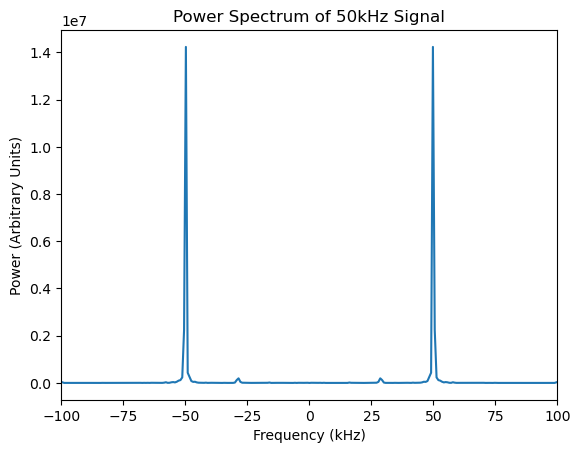

In [50]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(power))
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Power Spectrum of 50kHz Signal")
plt.show()



49.8046875


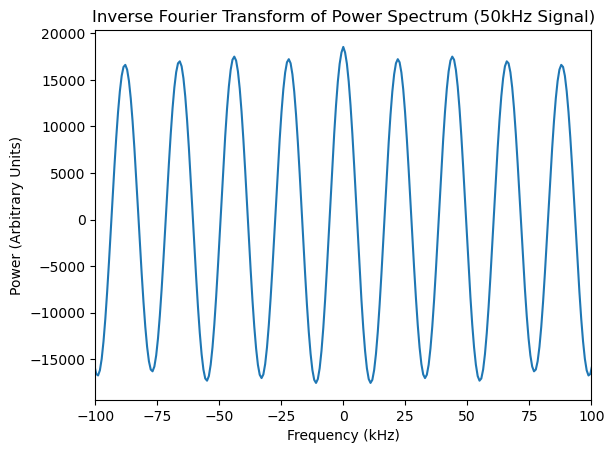

In [68]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2
power_ifft = np.fft.ifft(power)

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(power_ifft))
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Inverse Fourier Transform of Power Spectrum (50kHz Signal)")
plt.show()

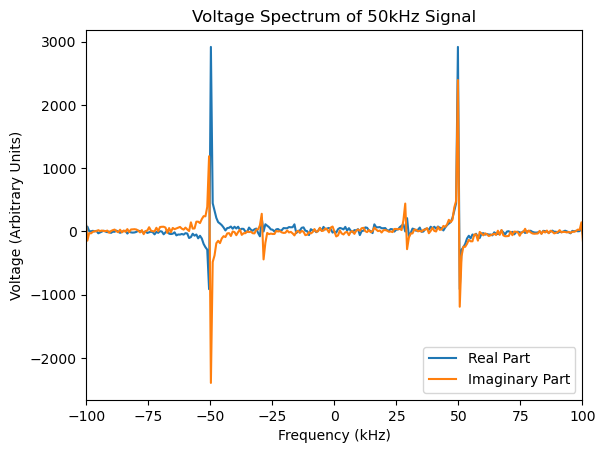

In [58]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
volt_real = np.real(fft_data)
volt_imag = np.imag(fft_data)

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_real), label="Real Part")
plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_imag), label="Imaginary Part")
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Voltage (Arbitrary Units)")
plt.title("Voltage Spectrum of 50kHz Signal")
plt.legend()
plt.show()